# Production Hybrid Prophet + GRU Model

**Purpose:** Demonstrate the deployable production Hybrid model trained on the complete high-quality dataset with a fixed container-level holdout for generalization evaluation.

**Important:** This notebook loads saved production artifacts and **generates all visualizations in-notebook**. It does not display pre-rendered PNGs.

Training is executed only via `production/scripts/train_production_hybrid.py`.

In [1]:
import json
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display

# Resolve repo root whether the kernel cwd is repo/ or repo/notebooks/
_candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path('..').resolve(),
    Path('.').resolve(),
]
REPO_ROOT = next(
    (p for p in _candidates if (p / 'production' / 'hybrid' / 'models' / 'model.keras').exists()),
    Path('../..').resolve(),
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PROD = REPO_ROOT / 'production' / 'hybrid'
if not PROD.exists():
    raise FileNotFoundError(
        'Production artifacts missing. Run: '
        'tf_metal_env/bin/python production/scripts/train_production_hybrid.py'
    )

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')
FIG_DPI = 120
PALETTE = {'known': '#2563eb', 'unseen': '#f97316'}

print('Repo root:', REPO_ROOT)
print('Hybrid artifacts:', PROD)

from production.utils.artifacts import (
    load_production_scalers,
    load_residual_stats,
)
from production.utils.inference import (
    run_known_container_inference,
    run_unseen_container_inference,
)

def pick_container(preferred, available, label):
    """Resolve a user-entered container ID against an allowed pool."""
    available = sorted(str(c) for c in available)
    if not available:
        raise ValueError(f'No {label} containers available.')
    if preferred is None or str(preferred).strip() == '':
        chosen = available[0]
        print(f'No {label} ID set — using default: {chosen}')
        return chosen
    preferred = str(preferred).strip()
    if preferred not in available:
        partial = [c for c in available if preferred.lower() in c.lower()][:10]
        msg = (
            f"Unknown {label} container: {preferred!r}\n"
            f'Available: {len(available)} containers\n'
            f'Examples: {available[:10]}'
        )
        if partial:
            msg += f'\nPartial matches: {partial}'
        raise ValueError(msg)
    print(f'Selected {label} container: {preferred}')
    return preferred

def search_containers(query, available, limit=20):
    """Return container IDs containing the query substring."""
    q = str(query).strip().lower()
    matches = [c for c in sorted(available) if q in str(c).lower()]
    return matches[:limit]

def plot_container_forecast(result, title_prefix='Container'):
    """Generate forecast, residual, and error plots for one container."""
    cid = result.container_id
    ts = result.val_container['time_stamp'].values[:96]
    actual = np.ravel(result.actual_day1_real)
    hybrid = np.ravel(result.day1_final_real)
    prophet = np.ravel(result.prophet_day1_real)
    errors = hybrid - actual

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes[0, 0].plot(ts, actual, label='Actual', color='#2563eb', lw=1.8)
    axes[0, 0].plot(ts, hybrid, label='Hybrid', color='#ef4444', ls='--', lw=1.8)
    axes[0, 0].plot(ts, prophet, label='Prophet', color='#16a34a', alpha=0.75)
    axes[0, 0].set_title(f'{title_prefix} {cid} — Day-1 CPU forecast')
    axes[0, 0].set_ylabel('CPU (%)')
    axes[0, 0].legend()

    axes[0, 1].plot(ts, errors, color='#9333ea', lw=1.5)
    axes[0, 1].axhline(0, color='black', ls='--', alpha=0.4)
    axes[0, 1].set_title('Forecast error (Hybrid − Actual)')
    axes[0, 1].set_ylabel('Error (%)')

    axes[1, 0].plot(ts, result.day1_residual, color='#7c3aed', lw=1.5)
    axes[1, 0].set_title('GRU residual component')
    axes[1, 0].set_ylabel('Scaled residual')
    axes[1, 0].set_xlabel('Time')

    axes[1, 1].scatter(actual, hybrid, alpha=0.65, s=18, color='#2563eb')
    lim = max(actual.max(), hybrid.max())
    axes[1, 1].plot([0, lim], [0, lim], 'r--', lw=1)
    axes[1, 1].set_xlabel('Actual CPU (%)')
    axes[1, 1].set_ylabel('Predicted CPU (%)')
    axes[1, 1].set_title('Actual vs Hybrid scatter')

    for ax in axes[0, :].flat:
        ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    plt.show()

def container_metrics_table(eval_df, container_id):
    cols = [
        'container_id', 'split', 'train_steps', 'validation_steps',
        'day1_mae', 'day1_rmse', 'day1_mape', 'day1_pearson_r', 'day1_r2',
    ]
    row = eval_df.loc[eval_df['container_id'] == container_id, cols]
    if row.empty:
        print(f'No saved metrics for {container_id!r}. Metrics below are computed live.')
        return None
    return row.reset_index(drop=True)


Importing plotly failed. Interactive plots will not work.


Repo root: /Users/lehaan/Desktop/FYP_Long_Term
Hybrid artifacts: /Users/lehaan/Desktop/FYP_Long_Term/production/hybrid


## 1. Introduction

In [2]:
with (PROD / 'config' / 'production_config.json').open() as fh:
    prod_config = json.load(fh)
with (PROD / 'config' / 'training_metadata.json').open() as fh:
    train_meta = json.load(fh)
with (PROD / 'metadata' / 'container_split_metadata.json').open() as fh:
    split_meta = json.load(fh)

print('Model type:', prod_config['model_type'])
print('Input window:', prod_config['input_window'])
print('Forecast horizon:', prod_config['forecast_horizon'])
print('Train containers:', split_meta['n_train_containers'])
print('Unseen containers:', split_meta['n_unseen_containers'])

Model type: hybrid_prophet_gru
Input window: 96
Forecast horizon: 96
Train containers: 435
Unseen containers: 49


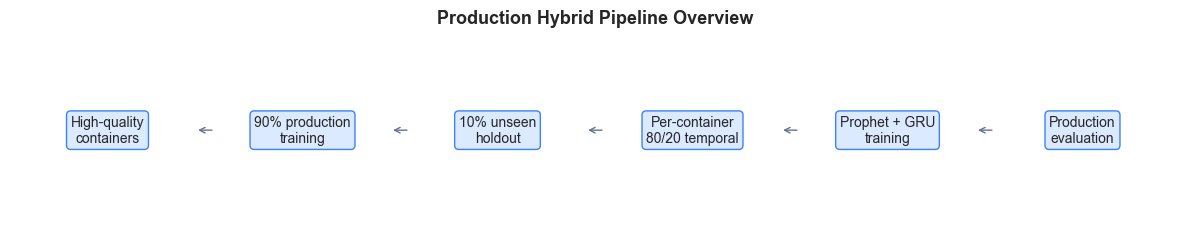

In [3]:
fig, ax = plt.subplots(figsize=(12, 2.5))
stages = [
    'High-quality\ncontainers',
    '90% production\ntraining',
    '10% unseen\nholdout',
    'Per-container\n80/20 temporal',
    'Prophet + GRU\ntraining',
    'Production\nevaluation',
]
x = np.arange(len(stages))
ax.barh(0, len(stages), color='none', edgecolor='none')
for i, label in enumerate(stages):
    ax.text(i, 0, label, ha='center', va='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='#dbeafe', edgecolor='#3b82f6'))
    if i < len(stages) - 1:
        ax.annotate('', xy=(i + 0.45, 0), xytext=(i + 0.55, 0),
                    arrowprops=dict(arrowstyle='->', color='#64748b'))
ax.set_xlim(-0.5, len(stages) - 0.5)
ax.set_ylim(-0.5, 0.5)
ax.axis('off')
ax.set_title('Production Hybrid Pipeline Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Production Dataset

In [4]:
with (PROD / 'metadata' / 'train_container_ids.json').open() as fh:
    train_ids = json.load(fh)['container_ids']
with (PROD / 'metadata' / 'unseen_container_ids.json').open() as fh:
    unseen_ids = json.load(fh)['container_ids']

train_df = pd.read_parquet(PROD / 'cache' / 'train_df.parquet')
val_df = pd.read_parquet(PROD / 'cache' / 'val_df.parquet')
unseen_raw = pd.read_parquet(PROD / 'cache' / 'unseen_resampled.parquet')

dataset_summary = pd.DataFrame([
    {'split': 'Production train (80%)', 'containers': train_df['container_id'].nunique(),
     'rows': len(train_df), 'period': 'historical 80% per container'},
    {'split': 'Production val (20%)', 'containers': val_df['container_id'].nunique(),
     'rows': len(val_df), 'period': 'temporal holdout 20%'},
    {'split': 'Unseen holdout (raw)', 'containers': unseen_raw['container_id'].nunique(),
     'rows': len(unseen_raw), 'period': 'full timeline (eval uses 80/20 locally)'},
])
display(dataset_summary)

,split,containers,rows,period
0,Production train (80%),435,266532,historical 80% per container
1,Production val (20%),435,66888,temporal holdout 20%
2,Unseen holdout (raw),49,37584,full timeline (eval uses 80/20 locally)


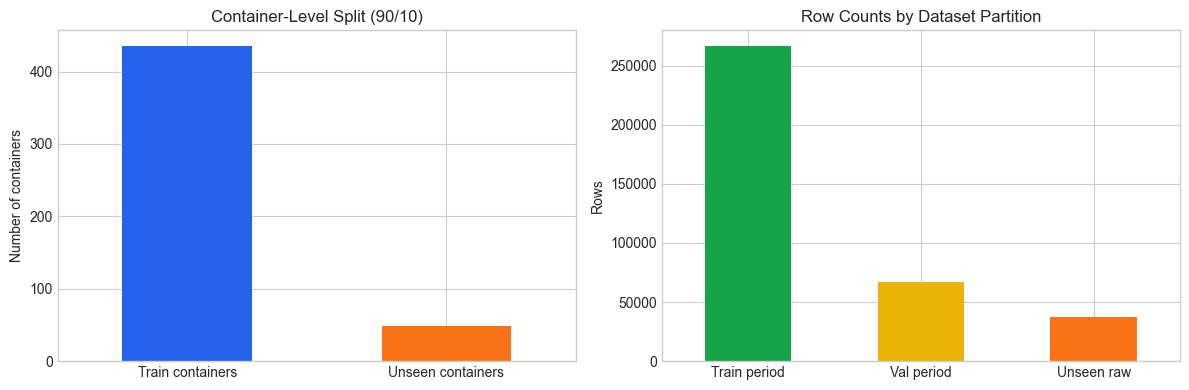

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
split_counts = pd.Series({'Train containers': len(train_ids), 'Unseen containers': len(unseen_ids)})
split_counts.plot(kind='bar', ax=axes[0], color=['#2563eb', '#f97316'], rot=0)
axes[0].set_title('Container-Level Split (90/10)')
axes[0].set_ylabel('Number of containers')

row_counts = pd.Series({
    'Train period': len(train_df),
    'Val period': len(val_df),
    'Unseen raw': len(unseen_raw),
})
row_counts.plot(kind='bar', ax=axes[1], color=['#16a34a', '#eab308', '#f97316'], rot=0)
axes[1].set_title('Row Counts by Dataset Partition')
axes[1].set_ylabel('Rows')
plt.tight_layout()
plt.show()

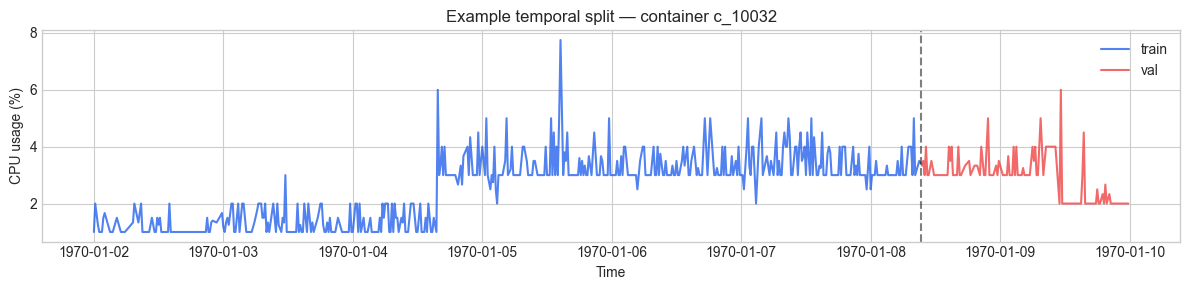

In [6]:
sample_cid = train_df['container_id'].iloc[0]
g = pd.concat([
    train_df[train_df['container_id'] == sample_cid].assign(partition='train'),
    val_df[val_df['container_id'] == sample_cid].assign(partition='val'),
])
fig, ax = plt.subplots(figsize=(12, 3))
for part, color in [('train', '#2563eb'), ('val', '#ef4444')]:
    sub = g[g['partition'] == part]
    ax.plot(sub['time_stamp'], sub['cpu'], label=part, color=color, alpha=0.8)
ax.axvline(g[g['partition'] == 'train']['time_stamp'].max(), color='black', ls='--', alpha=0.5)
ax.set_title(f'Example temporal split — container {sample_cid}')
ax.set_xlabel('Time')
ax.set_ylabel('CPU usage (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 3. Training Summary

In [7]:
history = pd.read_csv(PROD / 'logs' / 'training_history.csv')
display(history.tail())
print(f"Best epoch: {train_meta['best_epoch']}  |  "
      f"Best val loss: {train_meta['best_val_loss']:.6f}")

,epoch,loss,mae,val_loss,val_mae
6,7,1.032790,0.639588,1.038846,0.640654
7,8,1.032091,0.639038,1.038570,0.640478
8,9,1.031855,0.638862,1.038917,0.640145
9,10,1.032808,0.639532,1.038587,0.641340
10,11,1.032065,0.638984,1.038464,0.641206


Best epoch: 1  |  Best val loss: 1.036033


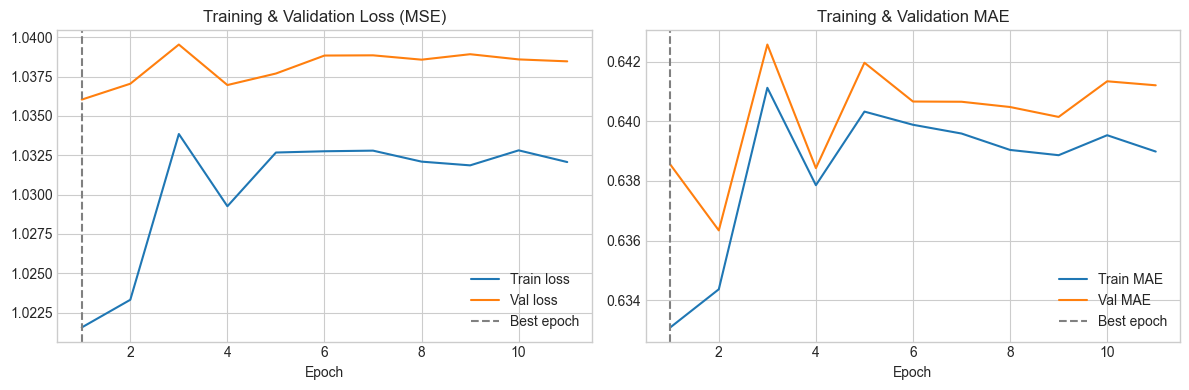

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['epoch'], history['loss'], label='Train loss')
axes[0].plot(history['epoch'], history['val_loss'], label='Val loss')
axes[0].axvline(train_meta['best_epoch'], color='gray', ls='--', label='Best epoch')
axes[0].set_title('Training & Validation Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['epoch'], history['mae'], label='Train MAE')
axes[1].plot(history['epoch'], history['val_mae'], label='Val MAE')
axes[1].axvline(train_meta['best_epoch'], color='gray', ls='--', label='Best epoch')
axes[1].set_title('Training & Validation MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

In [9]:
model = tf.keras.models.load_model(str(PROD / 'models' / 'model.keras'))
model.summary()
n_params = model.count_params()
print(f'Total parameters: {n_params:,}')

2026-07-27 02:24:48.114298: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-07-27 02:24:48.114367: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-27 02:24:48.114385: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-07-27 02:24:48.114426: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-27 02:24:48.114446: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 96, 256)        │       198,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 96, 128)        │       148,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │        12,384 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,215,266 (4.64 MB)

 Trainable params: 405,088 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 810,178 (3.09 MB)

Total parameters: 405,088


## 4. Production Evaluation

In [10]:
eval_df = pd.read_csv(PROD / 'metrics' / 'evaluation_results.csv')
display(eval_df.groupby('split').agg(
    containers=('container_id', 'count'),
    mae_mean=('day1_mae', 'mean'),
    rmse_mean=('day1_rmse', 'mean'),
    mape_mean=('day1_mape', 'mean'),
    pearson_mean=('day1_pearson_r', 'mean'),
    r2_mean=('day1_r2', 'mean'),
).round(4))

,containers,mae_mean,rmse_mean,mape_mean,pearson_mean,r2_mean
split,,,,,,
known,435,1.6878,2.3211,150.9146,0.4703,0.0824
unseen,49,1.9696,2.7389,39.9902,0.5232,-0.0948


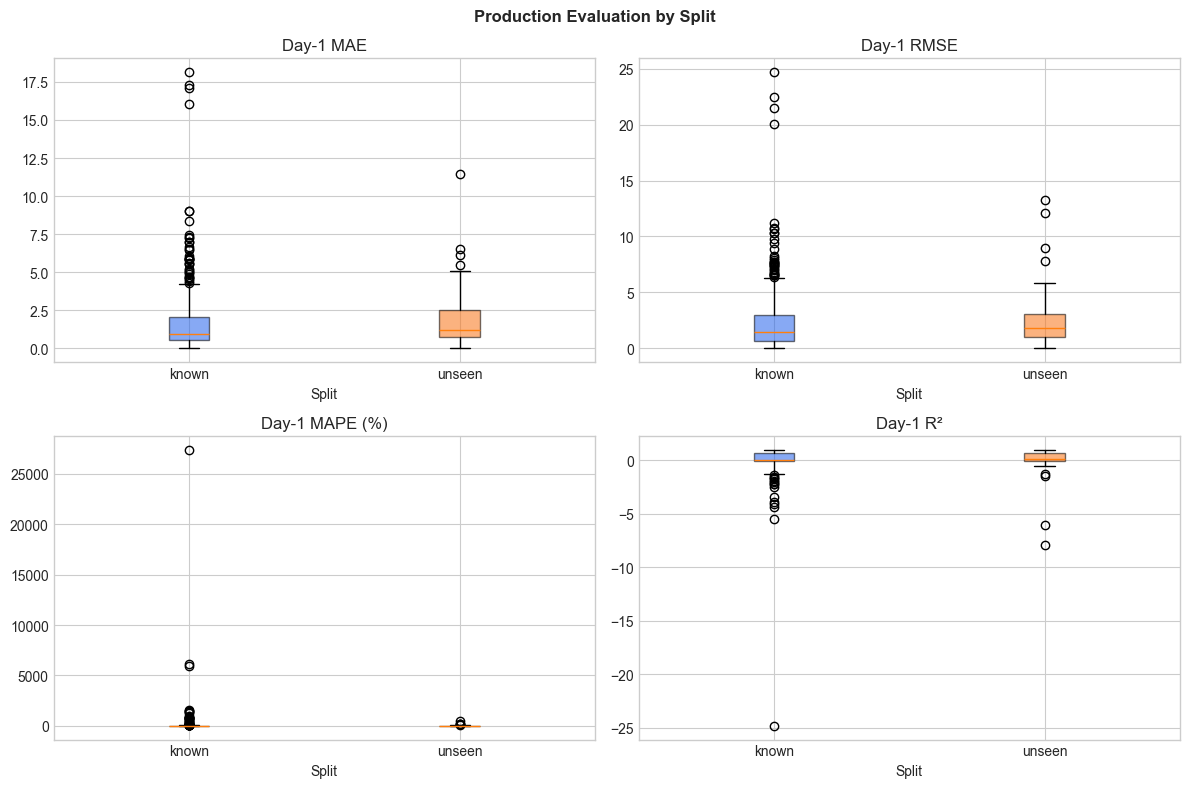

In [11]:
def _split_boxplot(ax, df, col, title):
    groups = [df.loc[df['split'] == s, col].dropna().values for s in ('known', 'unseen')]
    bp = ax.boxplot(groups, patch_artist=True)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['known', 'unseen'])
    for patch, split in zip(bp['boxes'], ('known', 'unseen')):
        patch.set_facecolor(PALETTE[split])
        patch.set_alpha(0.55)
    ax.set_title(title)
    ax.set_xlabel('Split')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col, title in zip(
    axes.ravel(),
    ['day1_mae', 'day1_rmse', 'day1_mape', 'day1_r2'],
    ['Day-1 MAE', 'Day-1 RMSE', 'Day-1 MAPE (%)', 'Day-1 R²'],
):
    _split_boxplot(ax, eval_df, col, title)
plt.suptitle('Production Evaluation by Split', fontweight='bold')
plt.tight_layout()
plt.show()

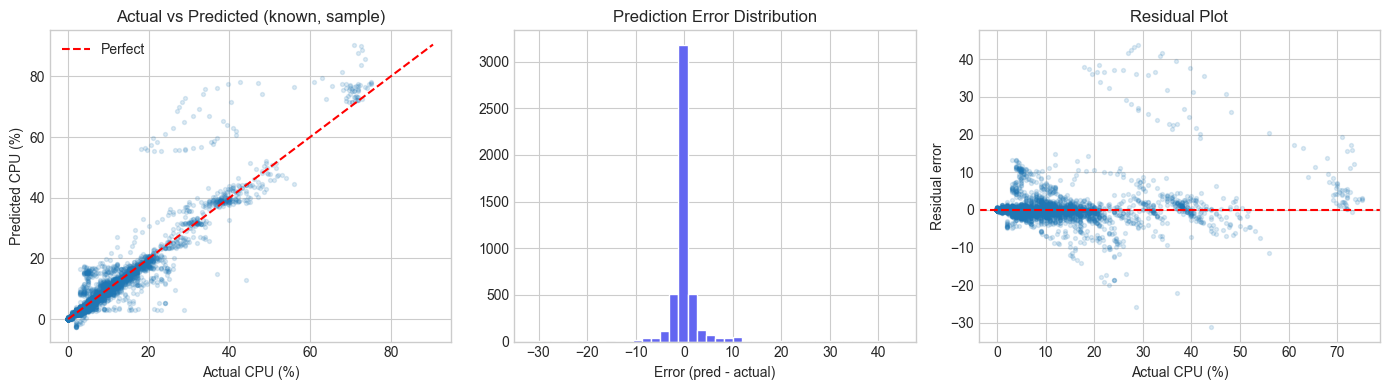

In [12]:
known_dir = PROD / 'predictions' / 'known'
all_actual, all_pred = [], []
for pkl in sorted(known_dir.glob('*.pkl'))[:50]:
    with pkl.open('rb') as fh:
        rec = pickle.load(fh)
    all_actual.extend(rec['actual_day1_real'].ravel())
    all_pred.extend(rec['day1_final_real'].ravel())
all_actual = np.array(all_actual)
all_pred = np.array(all_pred)
errors = all_pred - all_actual

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(all_actual, all_pred, alpha=0.15, s=8)
mx = max(all_actual.max(), all_pred.max())
axes[0].plot([0, mx], [0, mx], 'r--', label='Perfect')
axes[0].set_xlabel('Actual CPU (%)')
axes[0].set_ylabel('Predicted CPU (%)')
axes[0].set_title('Actual vs Predicted (known, sample)')
axes[0].legend()

axes[1].hist(errors, bins=40, color='#6366f1', edgecolor='white')
axes[1].set_title('Prediction Error Distribution')
axes[1].set_xlabel('Error (pred - actual)')

axes[2].scatter(all_actual, errors, alpha=0.15, s=8)
axes[2].axhline(0, color='r', ls='--')
axes[2].set_xlabel('Actual CPU (%)')
axes[2].set_ylabel('Residual error')
axes[2].set_title('Residual Plot')
plt.tight_layout()
plt.show()

## 5. Known Container — pick your container

Edit `PREFERRED_KNOWN_CONTAINER` below to any training-container ID (e.g. `"c_1016"`). Leave as `None` to use the first available container.

Re-run **this cell and the next cell** after changing the ID.

In [27]:
scalers = load_production_scalers()
res_mean, res_std, input_window, _ = load_residual_stats()

known_cids = eval_df.loc[eval_df['split'] == 'known', 'container_id'].unique()
unseen_cids = eval_df.loc[eval_df['split'] == 'unseen', 'container_id'].unique()

# ===== EDIT THIS =====
PREFERRED_KNOWN_CONTAINER = 'c_11461'  # e.g. 'c_1016'
# =====================

SELECTED_KNOWN = pick_container(PREFERRED_KNOWN_CONTAINER, known_cids, 'known')
print('Available known containers:', len(known_cids))
print('Search tip: search_containers("1016", known_cids)')

Selected known container: c_11461
Available known containers: 435
Search tip: search_containers("1016", known_cids)


02:28:43 - cmdstanpy - INFO - Chain [1] start processing
02:28:43 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


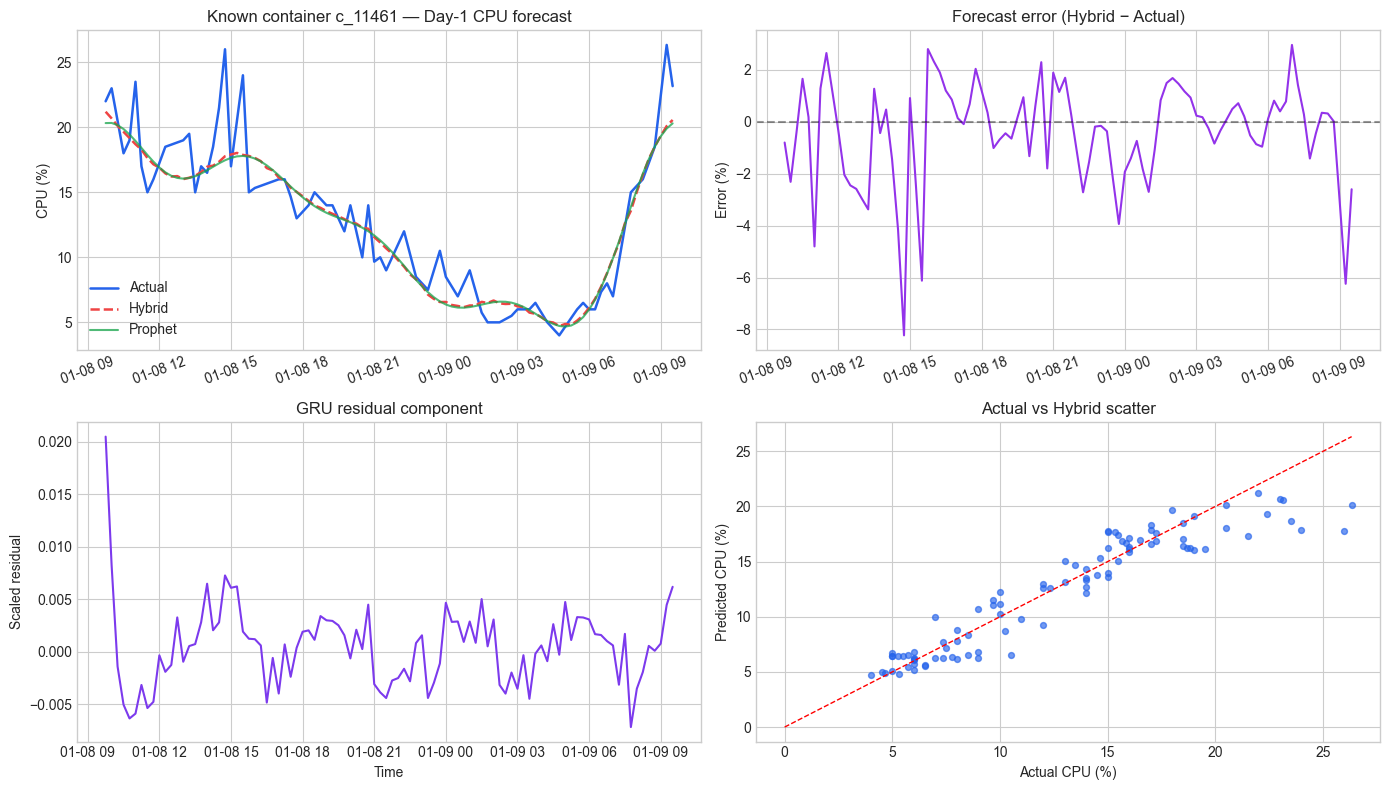

,container_id,split,train_steps,validation_steps,day1_mae,day1_rmse,day1_mape,day1_pearson_r,day1_r2
0,c_11461,known,609,153,1.45277,2.023104,11.807757,0.941148,0.876799


,container_id,live_mae,live_rmse
0,c_11461,1.45277,2.023104


In [28]:
known_result = run_known_container_inference(
    SELECTED_KNOWN, train_df, val_df, model, scalers, res_mean, res_std, input_window
)
plot_container_forecast(known_result, title_prefix='Known container')

metrics = container_metrics_table(eval_df, SELECTED_KNOWN)
if metrics is not None:
    display(metrics)

live = pd.DataFrame([{
    'container_id': SELECTED_KNOWN,
    'live_mae': float(np.mean(np.abs(
        np.ravel(known_result.day1_final_real) - np.ravel(known_result.actual_day1_real)
    ))),
    'live_rmse': float(np.sqrt(np.mean((
        np.ravel(known_result.day1_final_real) - np.ravel(known_result.actual_day1_real)
    ) ** 2))),
}])
display(live)

## 6. Unseen Container — pick your container

Edit `PREFERRED_UNSEEN_CONTAINER` to any holdout-container ID. Leave as `None` for the default first unseen container.

Re-run **this cell and the next cell** after changing the ID.

In [57]:
# ===== EDIT THIS =====
PREFERRED_UNSEEN_CONTAINER = 'c_39702'  # e.g. 'c_23456'
# =====================

SELECTED_UNSEEN = pick_container(PREFERRED_UNSEEN_CONTAINER, unseen_cids, 'unseen')
print('Available unseen containers:', len(unseen_cids))
print('Search tip: search_containers("2345", unseen_cids)')

Selected unseen container: c_39702
Available unseen containers: 49
Search tip: search_containers("2345", unseen_cids)


17:02:16 - cmdstanpy - INFO - Chain [1] start processing
17:02:16 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


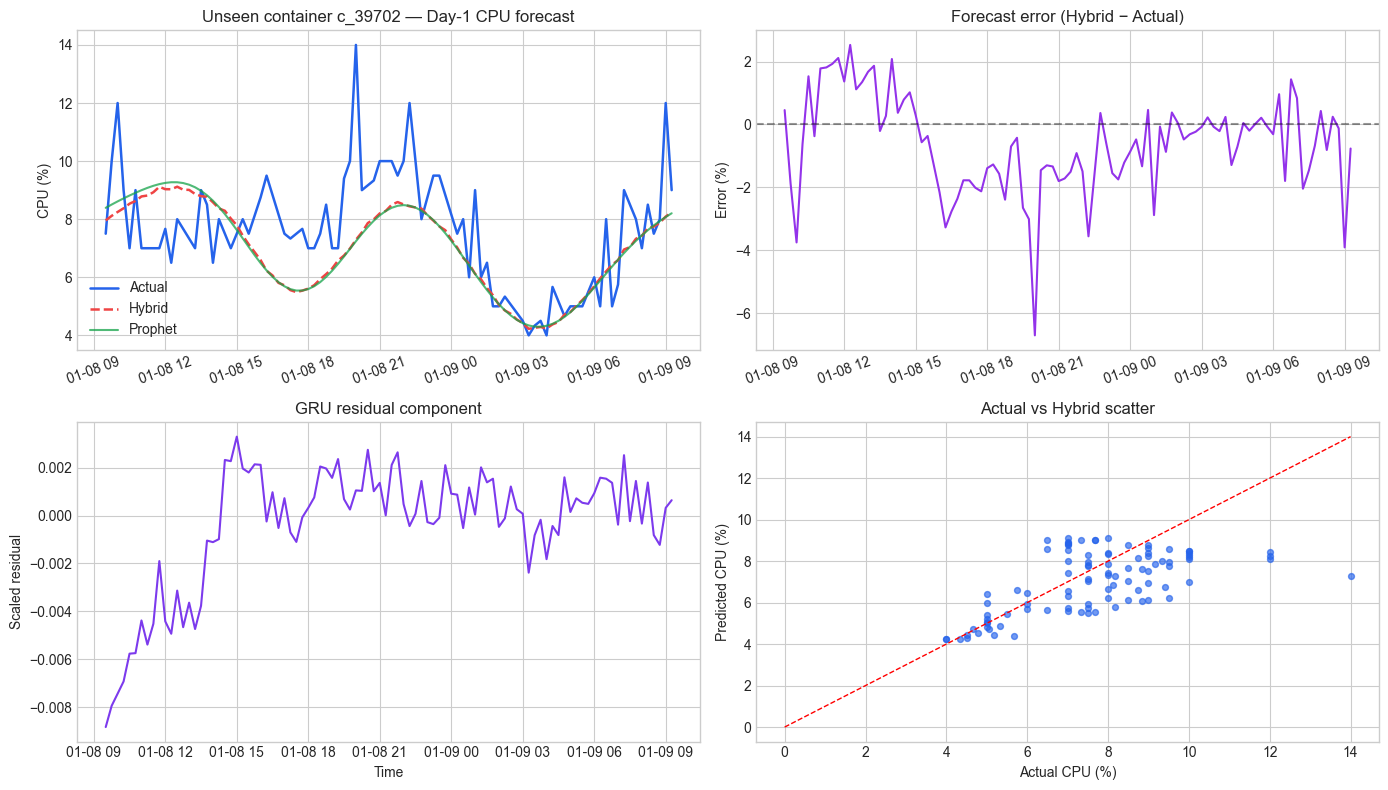

,container_id,split,train_steps,validation_steps,day1_mae,day1_rmse,day1_mape,day1_pearson_r,day1_r2
0,c_39702,unseen,613,154,1.265539,1.657248,15.357182,0.618902,0.250937


,container_id,live_mae,live_rmse
0,c_39702,1.265539,1.657248


In [58]:
unseen_result = run_unseen_container_inference(
    SELECTED_UNSEEN, unseen_raw, model, res_mean, res_std, input_window
)
plot_container_forecast(unseen_result, title_prefix='Unseen container')

metrics = container_metrics_table(eval_df, SELECTED_UNSEEN)
if metrics is not None:
    display(metrics)

live = pd.DataFrame([{
    'container_id': SELECTED_UNSEEN,
    'live_mae': float(np.mean(np.abs(
        np.ravel(unseen_result.day1_final_real) - np.ravel(unseen_result.actual_day1_real)
    ))),
    'live_rmse': float(np.sqrt(np.mean((
        np.ravel(unseen_result.day1_final_real) - np.ravel(unseen_result.actual_day1_real)
    ) ** 2))),
}])
display(live)

## 7. Container ID lookup (optional)

In [48]:
LOOKUP_QUERY = '1016'  # change substring to search known/unseen IDs

lookup = pd.DataFrame({
    'known_matches': pd.Series(search_containers(LOOKUP_QUERY, known_cids, limit=15)),
    'unseen_matches': pd.Series(search_containers(LOOKUP_QUERY, unseen_cids, limit=15)),
})
display(lookup)

,known_matches,unseen_matches
0,c_1016,NaN


## 8. Known vs Unseen Comparison

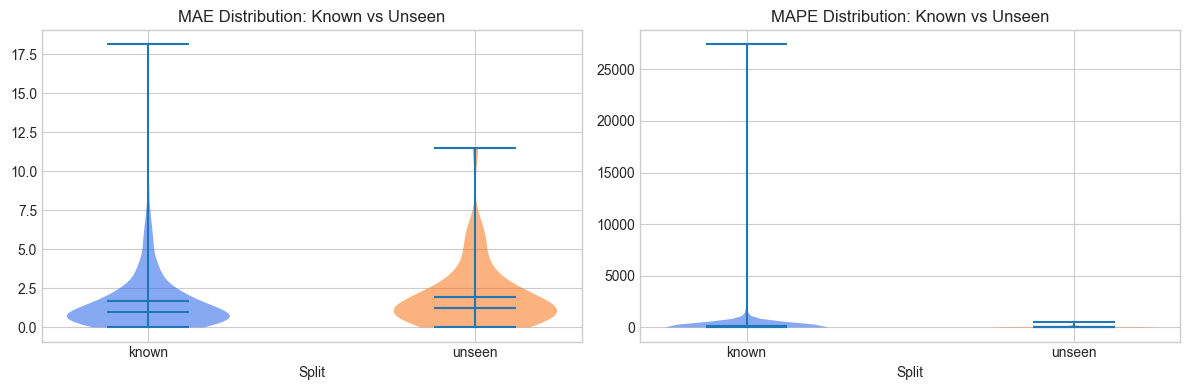

In [41]:
def _split_violin(ax, df, col, title):
    groups = [df.loc[df['split'] == s, col].dropna().values for s in ('known', 'unseen')]
    parts = ax.violinplot(groups, showmeans=True, showmedians=True)
    for idx, body in enumerate(parts['bodies']):
        body.set_facecolor(list(PALETTE.values())[idx])
        body.set_alpha(0.55)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['known', 'unseen'])
    ax.set_title(title)
    ax.set_xlabel('Split')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
_split_violin(axes[0], eval_df, 'day1_mae', 'MAE Distribution: Known vs Unseen')
_split_violin(axes[1], eval_df, 'day1_mape', 'MAPE Distribution: Known vs Unseen')
plt.tight_layout()
plt.show()

In [42]:
comparison = eval_df.groupby('split')[
    ['day1_mae', 'day1_rmse', 'day1_mape', 'day1_pearson_r', 'day1_r2']
].agg(['mean', 'std', 'median']).round(4)
display(comparison)

day1_mae                 day1_rmse                 day1_mape  \
           mean     std  median      mean     std  median      mean   
split                                                                 
known    1.6878  2.1839  0.9726    2.3211  2.8682  1.4209  150.9146   
unseen   1.9696  2.0978  1.2257    2.7389  2.8157  1.8011   39.9902   

                           day1_pearson_r                 day1_r2          \
              std   median           mean     std  median    mean     std   
split                                                                       
known   1383.2996  17.5595         0.4703  0.4007  0.4506  0.0824  1.4023   
unseen    78.8174  19.8892         0.5232  0.3639  0.5974 -0.0948  1.5455   

                
        median  
split           
known   0.0477  
unseen  0.0966

## 9. Model Summary

In [43]:
summary_table = pd.DataFrame([
    {'Property': 'Architecture', 'Value': 'Prophet + 3-layer GRU Hybrid'},
    {'Property': 'Input shape', 'Value': f"({prod_config['input_window']}, 1)"},
    {'Property': 'Output shape', 'Value': f"({prod_config['forecast_horizon']},)"},
    {'Property': 'Parameters', 'Value': f'{n_params:,}'},
    {'Property': 'Optimizer', 'Value': prod_config['optimizer']},
    {'Property': 'Loss', 'Value': prod_config['loss']},
    {'Property': 'Batch size', 'Value': train_meta['batch_size']},
    {'Property': 'Best epoch', 'Value': train_meta['best_epoch']},
    {'Property': 'Residual norm', 'Value': prod_config['residual_normalization']},
])
display(summary_table)

,Property,Value
0,Architecture,Prophet + 3-layer GRU Hybrid
1,Input shape,"(96, 1)"
2,Output shape,"(96,)"
3,Parameters,"405,088"
4,Optimizer,adam
5,Loss,mse
6,Batch size,64
7,Best epoch,1
8,Residual norm,global


## 10. Conclusions

In [44]:
known_mae = eval_df.loc[eval_df['split'] == 'known', 'day1_mae'].mean()
unseen_mae = eval_df.loc[eval_df['split'] == 'unseen', 'day1_mae'].mean()
gap = unseen_mae - known_mae if pd.notna(unseen_mae) and pd.notna(known_mae) else np.nan

print('Production readiness assessment')
print('-' * 50)
print(f'Mean Day-1 MAE (known):   {known_mae:.4f} %')
print(f'Mean Day-1 MAE (unseen):  {unseen_mae:.4f} %')
print(f'Generalization gap:       {gap:.4f} %')
print()
print('Deployment notes:')
print('• Load model.keras + scalers.pkl + residual_stats.pkl for inference')
print('• For new containers: fit Prophet + scaler on historical 80% only')
print('• Apply global res_mean/res_std from residual_stats.pkl')
print('• Primary forecast horizon: 96 steps (24 h at 15-min resolution)')

Production readiness assessment
--------------------------------------------------
Mean Day-1 MAE (known):   1.6878 %
Mean Day-1 MAE (unseen):  1.9696 %
Generalization gap:       0.2818 %

Deployment notes:
• Load model.keras + scalers.pkl + residual_stats.pkl for inference
• For new containers: fit Prophet + scaler on historical 80% only
• Apply global res_mean/res_std from residual_stats.pkl
• Primary forecast horizon: 96 steps (24 h at 15-min resolution)


## 11. Retrain Production Model (disabled by default)

In [45]:
RUN_TRAINING = False  # Set True only to retrain from the notebook

if RUN_TRAINING:
    import subprocess
    subprocess.run(
        [sys.executable, str(REPO_ROOT / 'production' / 'scripts' / 'train_production_hybrid.py')],
        check=True,
        cwd=str(REPO_ROOT),
    )
    print('Retraining complete. Re-run notebook cells to refresh artifacts.')
else:
    print('Retraining disabled. Use production/scripts/train_production_hybrid.py to train.')

Retraining disabled. Use production/scripts/train_production_hybrid.py to train.
